This notebook shows the steps to reproduce the calculations to create the fit coefficients used as input for the CATHERINA module. It however needs some adaptations to reproduce the same data currently used as input in data/input/fit.

In [ ]:
import pandas as pd
import numpy as np
from skrub import TableReport
from pprint import pprint
from scipy.optimize import curve_fit
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd

In [ ]:
tracks = pd.read_csv("../data/input/ibtracs.since1980.list.v04r01.csv", skiprows=[1])
tracks["ISO_TIME"] = pd.to_datetime(tracks["ISO_TIME"])
tracks = tracks.sort_values(by=["SID", "ISO_TIME"])

/tmp/ipykernel_912/4122938090.py:2: DtypeWarning: Columns (19,20,23,172,173) have mixed types. Specify dtype option on import or set low_memory=False.
  tracks = pd.read_csv("data/input/ibtracs.since1980.list.v04r01.csv", skiprows=[1])


In [7]:
tracks.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
0,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 00:00:00,TS,-12.5,172.5,...,,,,,,,,,6,350
1,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 03:00:00,TS,-12.2,172.4,...,,,,,,,,,6,350
2,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 06:00:00,TS,-11.9,172.4,...,,,,,,,,,5,360
3,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 09:00:00,TS,-11.7,172.4,...,,,,,,,,,4,10
4,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 12:00:00,TS,-11.5,172.5,...,,,,,,,,,4,20


In [8]:
TableReport(tracks)

Processing column 174 / 174


<TableReport: use .open() to display>

In [10]:
# pprint(tracks.columns.tolist())

In [11]:
# TODO: add all relevant filters as per the original paper
# TODO: add check isotime delta is 3hours

In [9]:
subtracks = tracks[["SID", "NUMBER", "ISO_TIME", "BASIN", "LAT", "LON"]]

In [10]:
subtracks

,SID,NUMBER,ISO_TIME,BASIN,LAT,LON
0,1980001S13173,1,1980-01-01 00:00:00,SP,-12.5,172.5
1,1980001S13173,1,1980-01-01 03:00:00,SP,-12.2,172.4
2,1980001S13173,1,1980-01-01 06:00:00,SP,-11.9,172.4
3,1980001S13173,1,1980-01-01 09:00:00,SP,-11.7,172.4
4,1980001S13173,1,1980-01-01 12:00:00,SP,-11.5,172.5
...,...,...,...,...,...,...
304134,2025333N05105,104,2025-11-29 18:00:00,WP,5.6,108.5
304135,2025333N05105,104,2025-11-29 21:00:00,WP,6.0,108.9
304136,2025333N05105,104,2025-11-30 00:00:00,WP,6.4,109.1
304137,2025333N05105,104,2025-11-30 03:00:00,WP,6.9,109.2


In [11]:
subtracks["DELTA_LAT"] = subtracks.groupby("SID")["LAT"].diff()
subtracks['DELTA_LAT_PREV'] = subtracks.groupby('SID')['DELTA_LAT'].shift(1)
subtracks["DELTA_LON"] = subtracks.groupby("SID")["LON"].diff()
subtracks['DELTA_LON_PREV'] = subtracks.groupby('SID')['DELTA_LON'].shift(1)

/tmp/ipykernel_912/846607528.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subtracks["DELTA_LAT"] = subtracks.groupby("SID")["LAT"].diff()
/tmp/ipykernel_912/846607528.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subtracks['DELTA_LAT_PREV'] = subtracks.groupby('SID')['DELTA_LAT'].shift(1)
/tmp/ipykernel_912/846607528.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

In [12]:
subtracks

,SID,NUMBER,ISO_TIME,BASIN,LAT,LON,DELTA_LAT,DELTA_LAT_PREV,DELTA_LON,DELTA_LON_PREV
0,1980001S13173,1,1980-01-01 00:00:00,SP,-12.5,172.5,NaN,NaN,NaN,NaN
1,1980001S13173,1,1980-01-01 03:00:00,SP,-12.2,172.4,0.3,NaN,-0.1,NaN
2,1980001S13173,1,1980-01-01 06:00:00,SP,-11.9,172.4,0.3,0.3,0.0,-0.1
3,1980001S13173,1,1980-01-01 09:00:00,SP,-11.7,172.4,0.2,0.3,0.0,0.0
4,1980001S13173,1,1980-01-01 12:00:00,SP,-11.5,172.5,0.2,0.2,0.1,0.0
...,...,...,...,...,...,...,...,...,...,...
304134,2025333N05105,104,2025-11-29 18:00:00,WP,5.6,108.5,0.2,0.2,0.5,0.5
304135,2025333N05105,104,2025-11-29 21:00:00,WP,6.0,108.9,0.4,0.2,0.4,0.5
304136,2025333N05105,104,2025-11-30 00:00:00,WP,6.4,109.1,0.4,0.4,0.2,0.4
304137,2025333N05105,104,2025-11-30 03:00:00,WP,6.9,109.2,0.5,0.4,0.1,0.2


In [21]:
subtracks.loc[subtracks["SID"]=="2026023S13120"]

,SID,NUMBER,ISO_TIME,BASIN,LAT,LON,DELTA_LAT,DELTA_LAT_PREV,DELTA_LON,DELTA_LON_PREV


In [22]:
data_lat = subtracks.dropna(subset=["DELTA_LAT", "DELTA_LAT_PREV"])
data_lon = subtracks.dropna(subset=["DELTA_LON", "DELTA_LON_PREV", "LON"])

# Global model

## LAT

In [23]:
X, y = data_lat[["DELTA_LAT_PREV"]], data_lat["DELTA_LAT"]

In [24]:
X

,DELTA_LAT_PREV
2,0.3
3,0.3
4,0.2
5,0.2
6,0.2
...,...
304134,0.2
304135,0.2
304136,0.4
304137,0.4


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [27]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
y_pred = lr.predict(X_test)

In [29]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")


MSE: 0.0129
RMSE: 0.1136
R^2: 0.8914


In [30]:
print("Coefficients:", lr.coef_)
print("Intercept:", lr.intercept_)


Coefficients: [0.95700435]
Intercept: 0.004331225539674438


In [34]:
print(y_pred.shape)
print(y.shape)

(58869,)
(294344,)


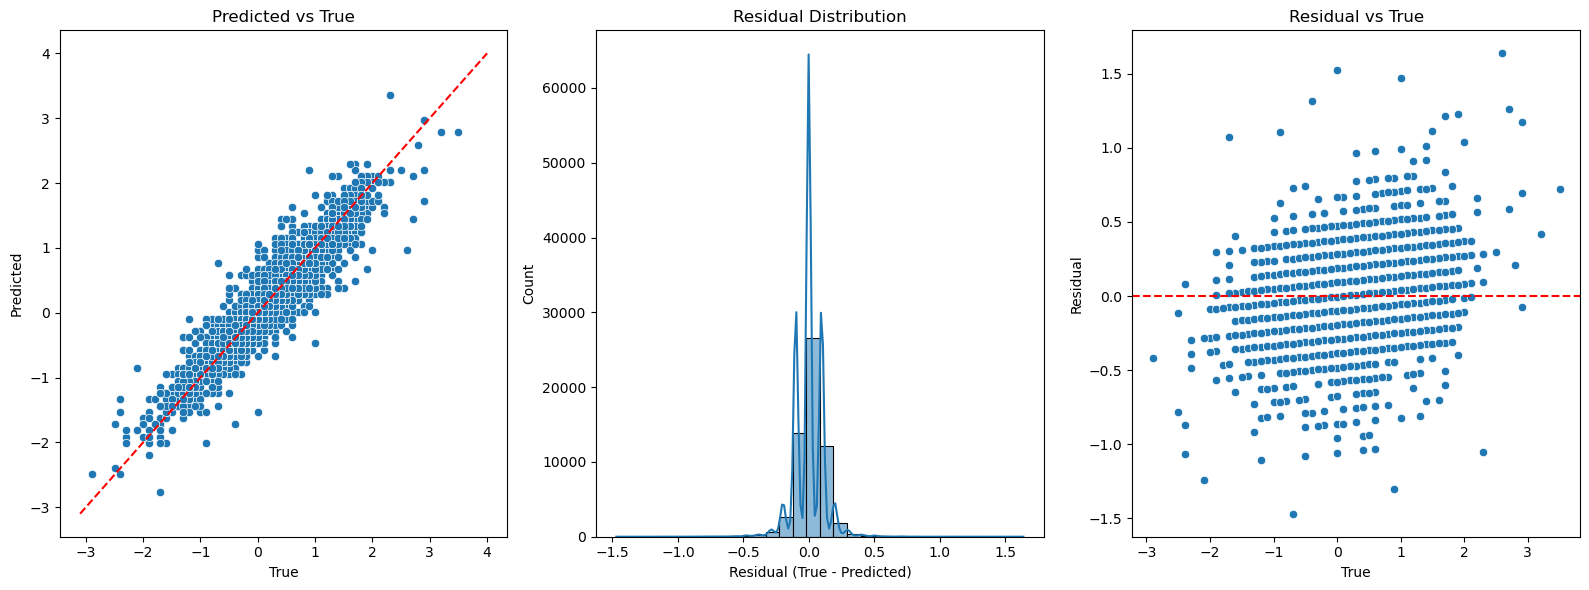

In [36]:
# Create figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# 1️⃣ Predicted vs True
# sns.scatterplot(x=y, y=y_pred, ax=axes[0])
sns.scatterplot(x=y_test, y=y_pred, ax=axes[0])
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
axes[0].set_xlabel("True")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Predicted vs True")

# 2️⃣ Residual histogram
# residuals = y - y_pred
residuals = y_test - y_pred
sns.histplot(residuals, bins=30, kde=True, ax=axes[1])
axes[1].set_xlabel("Residual (True - Predicted)")
axes[1].set_title("Residual Distribution")

# 3️⃣ Residual vs True
sns.scatterplot(x=y, y=residuals, ax=axes[2])
axes[2].axhline(0, color='red', linestyle='--')  # reference line at 0
axes[2].set_xlabel("True")
axes[2].set_ylabel("Residual")
axes[2].set_title("Residual vs True")

plt.tight_layout()
plt.show()

## LON

In [37]:
X, y = data_lon[["DELTA_LON_PREV", "LON"]].values.T, data_lon["DELTA_LON"].values

In [39]:
def nonlinear_model(X, b0, b1, b2) -> float:
    epsilon = 1e-15

    # X can be multiple features: e.g., X[0]=delta_lat_prev, X[1]=other_feature
    delta_lon_prev = X[0]
    inv_lon = 1./(X[1]+epsilon)  # optional
    
    return b0 + b1 * delta_lon_prev + b2 * inv_lon


In [40]:
popt, pcov = curve_fit(nonlinear_model, X, y, p0=[0.01, 0.01, 0.01])


In [41]:
alpha, beta, gamma = popt
print(f"Fitted parameters: alpha={alpha:.4f}, beta={beta:.4f}, gamma={gamma:.4f}")

Fitted parameters: alpha=0.0064, beta=0.9881, gamma=0.0000


# Basin model

## LAT

In [53]:
results = []

# for basin, df_basin in data.groupby('BASIN'):
for basin, df_basin in data_lat.groupby('BASIN'):
    
    # Features and target
    X = df_basin[['DELTA_LAT_PREV']]
    y = df_basin['DELTA_LAT']
    
    # Train-test split (you can stratify by time if needed)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    n_train = len(X_train)

    # Fit Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    
    # Predictions
    y_pred = lr.predict(X_test)
    
    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results.append({
        'basin': basin,
        'coef': lr.coef_[0],
        'intercept': lr.intercept_,
        'mse': mse,
        'r2': r2,
        "n_train": n_train
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)


  basin      coef  intercept       mse        r2  n_train
0    EP  0.928228   0.009716  0.006560  0.840380    37773
1    NI  0.747726   0.040076  0.020903  0.565377    11612
2    SA  0.956005  -0.003608  0.020458  0.657090       90
3    SI  0.916565  -0.015500  0.011658  0.800853    50392
4    SP  0.943514  -0.016691  0.014411  0.871092    24277
5    WP  0.933684   0.018102  0.014629  0.847024    79468


## LON

In [54]:
results = []

for basin, df_basin in data_lon.groupby('BASIN'):
    # Drop rows with NaNs in required columns
    df_basin = df_basin.dropna(subset=['DELTA_LON', 'DELTA_LON_PREV', 'LON'])
    
    if len(df_basin) < 3:
        # Skip very small groups
        continue
    
    y = df_basin['DELTA_LON'].values
    X = np.vstack((df_basin['DELTA_LON_PREV'].values, df_basin['LON'].values))
    n_train = len(y)
    
    # Fit nonlinear model with safe initial guesses
    try:
        popt, pcov = curve_fit(nonlinear_model, X, y, p0=[1,1,1], maxfev=10000)
        y_pred = nonlinear_model(X, *popt)
        
        mse = mean_squared_error(y, y_pred)
        r2 = r2_score(y, y_pred)
        
        results.append({
            'basin': basin,
            'alpha': popt[0],
            'beta': popt[1],
            'gamma': popt[2],
            'mse': mse,
            'r2': r2, 
            "n_train": n_train
        })
    except Exception as e:
        print(f"Could not fit basin {basin}: {e}")
        continue

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)


  basin     alpha      beta     gamma       mse        r2  n_train
0    EP -0.008027  0.976742 -0.322075  0.009050  0.932437    47217
1    NI  0.014018  0.853491 -2.749808  0.031510  0.707178    14516
2    SA  0.110555  1.022786  3.613959  0.022139  0.922657      113
3    SI -0.009791  0.967353  0.790258  0.016477  0.891589    62990
4    SP  0.014474  0.975546 -1.080619  0.026736  0.902305    30347
5    WP  0.012028  0.992244 -0.350676  0.023368  0.939788    99336


# Grid model

## LAT

In [55]:
data_lat

,SID,NUMBER,ISO_TIME,BASIN,LAT,LON,DELTA_LAT,DELTA_LAT_PREV,DELTA_LON,DELTA_LON_PREV
2,1980001S13173,1,1980-01-01 06:00:00,SP,-11.9,172.4,0.3,0.3,0.0,-0.1
3,1980001S13173,1,1980-01-01 09:00:00,SP,-11.7,172.4,0.2,0.3,0.0,0.0
4,1980001S13173,1,1980-01-01 12:00:00,SP,-11.5,172.5,0.2,0.2,0.1,0.0
5,1980001S13173,1,1980-01-01 15:00:00,SP,-11.3,172.6,0.2,0.2,0.1,0.1
6,1980001S13173,1,1980-01-01 18:00:00,SP,-11.2,172.7,0.1,0.2,0.1,0.1
...,...,...,...,...,...,...,...,...,...,...
304134,2025333N05105,104,2025-11-29 18:00:00,WP,5.6,108.5,0.2,0.2,0.5,0.5
304135,2025333N05105,104,2025-11-29 21:00:00,WP,6.0,108.9,0.4,0.2,0.4,0.5
304136,2025333N05105,104,2025-11-30 00:00:00,WP,6.4,109.1,0.4,0.4,0.2,0.4
304137,2025333N05105,104,2025-11-30 03:00:00,WP,6.9,109.2,0.5,0.4,0.1,0.2


In [59]:
import numpy as np
import pandas as pd

# Example bounding box
lat_min, lat_max = -90.,90.
lon_min, lon_max = -180.,180.

# Define grid resolution
grid_size = 0.5   # degrees (adjust as needed)

lat_grid = np.arange(lat_min, lat_max, grid_size)
lon_grid = np.arange(lon_min, lon_max, grid_size)

# Create grid points
grid = pd.DataFrame(
    [(lat, lon) for lat in lat_grid for lon in lon_grid],
    columns=['lat', 'lon']
)

grid = gpd.GeoDataFrame(
    grid,
    geometry=gpd.points_from_xy(grid.lon, grid.lat),
    crs="EPSG:4326"
)


In [60]:
grid

,lat,lon,geometry
0,-90.0,-180.0,POINT (-180 -90)
1,-90.0,-179.5,POINT (-179.5 -90)
2,-90.0,-179.0,POINT (-179 -90)
3,-90.0,-178.5,POINT (-178.5 -90)
4,-90.0,-178.0,POINT (-178 -90)
...,...,...,...
259195,89.5,177.5,POINT (177.5 89.5)
259196,89.5,178.0,POINT (178 89.5)
259197,89.5,178.5,POINT (178.5 89.5)
259198,89.5,179.0,POINT (179 89.5)


In [61]:
# IMPORTANT: project to metric CRS for distance filtering
points = gpd.GeoDataFrame(data_lat, geometry=gpd.points_from_xy(data_lat.LON, data_lat.LAT), crs="EPSG:4326")
points = points.to_crs("EPSG:3857")
grid = grid.to_crs("EPSG:3857")

In [62]:
radius = 5000  # meters

joined = gpd.sjoin_nearest(
    points,
    grid,
    how="left",
    max_distance=radius,
    distance_col="distance"
)


In [66]:
joined

,SID,NUMBER,ISO_TIME,BASIN,LAT,LON,DELTA_LAT,DELTA_LAT_PREV,DELTA_LON,DELTA_LON_PREV,geometry,index_right,lat,lon,distance
2,1980001S13173,1,1980-01-01 06:00:00,SP,-11.9,172.4,0.3,0.3,0.0,-0.1,POINT (19191480.213 -1334329.87),NaN,NaN,NaN,NaN
3,1980001S13173,1,1980-01-01 09:00:00,SP,-11.7,172.4,0.2,0.3,0.0,0.0,POINT (19191480.213 -1311585.307),NaN,NaN,NaN,NaN
4,1980001S13173,1,1980-01-01 12:00:00,SP,-11.5,172.5,0.2,0.2,0.1,0.0,POINT (19202612.162 -1288857.18),113745.0,-11.5,172.5,0.0
5,1980001S13173,1,1980-01-01 15:00:00,SP,-11.3,172.6,0.2,0.2,0.1,0.1,POINT (19213744.111 -1266145.189),NaN,NaN,NaN,NaN
6,1980001S13173,1,1980-01-01 18:00:00,SP,-11.2,172.7,0.1,0.2,0.1,0.1,POINT (19224876.06 -1254795.151),NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304134,2025333N05105,104,2025-11-29 18:00:00,WP,5.6,108.5,0.2,0.2,0.5,0.5,POINT (12078164.751 624384.044),NaN,NaN,NaN,NaN
304135,2025333N05105,104,2025-11-29 21:00:00,WP,6.0,108.9,0.4,0.2,0.4,0.5,POINT (12122692.547 669141.057),NaN,NaN,NaN,NaN
304136,2025333N05105,104,2025-11-30 00:00:00,WP,6.4,109.1,0.4,0.4,0.2,0.4,POINT (12144956.446 713930.923),NaN,NaN,NaN,NaN
304137,2025333N05105,104,2025-11-30 03:00:00,WP,6.9,109.2,0.5,0.4,0.1,0.2,POINT (12156088.395 769967.862),NaN,NaN,NaN,NaN


In [67]:
joined.head()

,SID,NUMBER,ISO_TIME,BASIN,LAT,LON,DELTA_LAT,DELTA_LAT_PREV,DELTA_LON,DELTA_LON_PREV,geometry,index_right,lat,lon,distance
2,1980001S13173,1,1980-01-01 06:00:00,SP,-11.9,172.4,0.3,0.3,0.0,-0.1,POINT (19191480.213 -1334329.87),NaN,NaN,NaN,NaN
3,1980001S13173,1,1980-01-01 09:00:00,SP,-11.7,172.4,0.2,0.3,0.0,0.0,POINT (19191480.213 -1311585.307),NaN,NaN,NaN,NaN
4,1980001S13173,1,1980-01-01 12:00:00,SP,-11.5,172.5,0.2,0.2,0.1,0.0,POINT (19202612.162 -1288857.18),113745.0,-11.5,172.5,0.0
5,1980001S13173,1,1980-01-01 15:00:00,SP,-11.3,172.6,0.2,0.2,0.1,0.1,POINT (19213744.111 -1266145.189),NaN,NaN,NaN,NaN
6,1980001S13173,1,1980-01-01 18:00:00,SP,-11.2,172.7,0.1,0.2,0.1,0.1,POINT (19224876.06 -1254795.151),NaN,NaN,NaN,NaN


In [69]:
joined.isna().sum()

SID                    0
NUMBER                 0
ISO_TIME               0
BASIN              39825
LAT                    0
LON                    0
DELTA_LAT              0
DELTA_LAT_PREV         0
DELTA_LON              0
DELTA_LON_PREV         0
geometry               0
index_right       276687
lat               276687
lon               276687
distance          276687
dtype: int64

In [70]:
joined.shape

(294344, 15)

In [63]:
assert len(points) == len(joined), "Row count changed after spatial join!"

In [64]:
TableReport(joined)

Processing column  15 / 15


,,,,,,,,,,,,,,,


In [ ]:
# REMOVE UNMATCHED POINTS
# joined = joined.dropna(subset=["grid_lat"])

Grid polygons instead of grid points

In [71]:
import geopandas as gpd
from shapely.geometry import box
import numpy as np

lat_min, lat_max = -90.,90.
lon_min, lon_max = -180.,180.
grid_size = 2

lat_grid = np.arange(lat_min, lat_max, grid_size)
lon_grid = np.arange(lon_min, lon_max, grid_size)

polygons = []
ids = []

i = 0
for lat in lat_grid:
    for lon in lon_grid:
        polygons.append(box(lon, lat,
                            lon + grid_size,
                            lat + grid_size))
        ids.append(i)
        i += 1

grid = gpd.GeoDataFrame(
    {"grid_id": ids},
    geometry=polygons,
    crs="EPSG:4326"
)


In [72]:
grid

,grid_id,geometry
0,0,"POLYGON ((-178 -90, -178 -88, -180 -88, -180 -..."
1,1,"POLYGON ((-176 -90, -176 -88, -178 -88, -178 -..."
2,2,"POLYGON ((-174 -90, -174 -88, -176 -88, -176 -..."
3,3,"POLYGON ((-172 -90, -172 -88, -174 -88, -174 -..."
4,4,"POLYGON ((-170 -90, -170 -88, -172 -88, -172 -..."
...,...,...
16195,16195,"POLYGON ((172 88, 172 90, 170 90, 170 88, 172 ..."
16196,16196,"POLYGON ((174 88, 174 90, 172 90, 172 88, 174 ..."
16197,16197,"POLYGON ((176 88, 176 90, 174 90, 174 88, 176 ..."
16198,16198,"POLYGON ((178 88, 178 90, 176 90, 176 88, 178 ..."


In [73]:
# IMPORTANT: project to metric CRS for distance filtering
points = gpd.GeoDataFrame(data_lat, geometry=gpd.points_from_xy(data_lat.LON, data_lat.LAT), crs="EPSG:4326")
points = points.to_crs("EPSG:3857")
grid = grid.to_crs("EPSG:3857")

In [74]:

joined = gpd.sjoin(
    grid,
    points,
    predicate="contains"
    )


In [75]:
TableReport(joined)

Processing column  13 / 13


,,,,,,,,,,,,,


<Axes: ylabel='Frequency'>

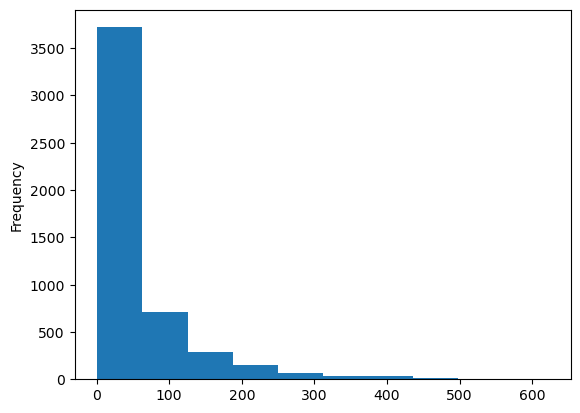

In [76]:
joined.groupby("grid_id").size().plot.hist()

In [77]:
(joined["grid_id"].value_counts() > 50).sum()/joined["grid_id"].nunique()

np.float64(0.31976974990075424)